# 1. Setup

In [1]:
!pip install langchain langchain-openai langchain-community langchain-classic openai wikipedia-api requests beautifulsoup4 PyPDF2 python-dotenv sentence-transformers transformers torch "gradio>=5.0,<6.0" -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 69.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.4/108.4 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 543.9/543.9 kB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires request

In [2]:
!apt-get update -qq
!apt-get install -y poppler-utils tesseract-ocr
!pip install pdf2image pytesseract pillow


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
The following NEW packages will be installed:
  poppler-utils
0 upgraded, 1 newly installed, 0 to remove and 80 not upgraded.
Need to get 186 kB of archives.
After this operation, 697 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 poppler-utils amd64 22.02.0-2ubuntu0.12 [186 kB]
Fetched 186 kB in 0s (5,036 kB/s)
Selecting previously unselected package poppler-utils.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../poppler-utils_22.02.0-2ubuntu0.12_amd64.deb ...
Unpacking poppler-utils (22.02.0-2ubuntu0.12) ...
Setting up poppler-utils (22

In [3]:
from langchain_openai import ChatOpenAI

In [4]:
import os, shutil

os.environ["PATH"] = "/opt/homebrew/bin:/usr/local/bin:" + os.environ.get("PATH", "")

print("PATH:", os.environ["PATH"])
print("tesseract:", shutil.which("tesseract"))
print("pdftoppm:", shutil.which("pdftoppm"))


PATH: /opt/homebrew/bin:/usr/local/bin:/opt/bin:/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:/sbin:/bin:/tools/node/bin:/tools/google-cloud-sdk/bin
tesseract: /usr/bin/tesseract
pdftoppm: /usr/bin/pdftoppm


In [5]:
import os
from dotenv import load_dotenv

# Local/PyCharm: load keys from a .env file in the project folder.
# Colab: fall back to Colab Secrets if available.
load_dotenv()

try:
    from google.colab import userdata
    for key in ["OPENAI_API_KEY", "SERPER_API_KEY", "WANDB_API_KEY"]:
        value = userdata.get(key)
        if value:
            os.environ[key] = value
except Exception:
    pass

missing_keys = [key for key in ["OPENAI_API_KEY", "SERPER_API_KEY"] if not os.getenv(key)]
if missing_keys:
    print("Missing API keys:", missing_keys)
    print("Local/PyCharm: create a .env file from .env.example. Colab: add them in Secrets.")
else:
    print("API keys loaded successfully.")

API keys loaded successfully.


# 2. Web Search Tool

In [6]:
# web search tool

import requests
from langchain.tools import tool

@tool
def web_search(query: str) -> str:
    """Search the web for current information. Use for up-to-date facts,
    recent events, statistics. Input should be a focused search query."""
    api_key = os.getenv("SERPER_API_KEY")
    if not api_key:
        return "Error: SERPER_API_KEY not set."

    url = "https://google.serper.dev/search"
    headers = {"X-API-KEY": api_key, "Content-Type": "application/json"}
    payload = {"q": query, "num": 5}

    try:
        response = requests.post(url, json=payload, headers=headers, timeout=10)
        response.raise_for_status()
        data = response.json()
    except requests.RequestException as e:
        return f"Error: {e}"

    results = []

    if "answerBox" in data:
        ab = data["answerBox"]
        answer = ab.get("answer") or ab.get("snippet") or ab.get("title", "")
        if answer:
            results.append(f"Quick Answer: {answer}")

    if "knowledgeGraph" in data:
        kg = data["knowledgeGraph"]
        if kg.get("title"):
            results.append(f"{kg['title']}: {kg.get('description', '')}")

    for i, item in enumerate(data.get("organic", [])[:5], 1):
        title = item.get("title", "No title")
        snippet = item.get("snippet", "No snippet")
        link = item.get("link", "")
        results.append(f"{i}. [{title}]({link})\n   {snippet}")

    return "\n\n".join(results) if results else "No results found."

/usr/local/lib/python3.12/dist-packages/langgraph/checkpoint/serde/encrypted.py:5: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


# 2. Wikipedia search tool


In [7]:
# wikipedia tool

import wikipediaapi

@tool
def wikipedia_search(query: str) -> str:
    """Search Wikipedia for background info, definitions, and context.
    Best for established facts, history, scientific concepts, biographies."""
    wiki = wikipediaapi.Wikipedia(
        user_agent="ResearchAssistantAgent/1.0",
        language="en",
    )
    page = wiki.page(query)

    if not page.exists():
        page = wiki.page(query.strip().title())
        if not page.exists():
            return f"No Wikipedia article found for '{query}'. Try a different term."

    summary = page.summary
    if len(summary) > 2000:
        summary = summary[:2000] + "..."

    sections = [s.title for s in page.sections if s.title]
    section_list = ", ".join(sections[:10]) if sections else "None"

    return f"**{page.title}**\nURL: {page.fullurl}\n\n{summary}\n\nSections: {section_list}"

# 2. fetch pdf tool

In [8]:
# pdf tool

import io
from PyPDF2 import PdfReader

@tool
def fetch_pdf(url: str) -> str:
    """Download and extract text from a PDF given its URL.
    Use for academic papers and reports."""
    if "arxiv.org/abs/" in url:
        url = url.replace("/abs/", "/pdf/")
        if not url.endswith(".pdf"):
            url += ".pdf"

    try:
        headers = {"User-Agent": "ResearchAssistantAgent/1.0"}
        response = requests.get(url, headers=headers, timeout=30)
        response.raise_for_status()

        reader = PdfReader(io.BytesIO(response.content))
        num_pages = len(reader.pages)
        max_pages = min(num_pages, 10)

        text_parts = []
        for i in range(max_pages):
            page_text = reader.pages[i].extract_text()
            if page_text:
                text_parts.append(f"--- Page {i+1} ---\n{page_text}")

        if not text_parts:
            return "Could not extract text. May be a scanned/image PDF."

        full_text = "\n\n".join(text_parts)
        if len(full_text) > 6000:
            full_text = full_text[:6000] + "\n\n[...truncated...]"

        return f"PDF: {url}\nPages: {num_pages} total ({max_pages} extracted)\n\n{full_text}"

    except Exception as e:
        return f"Error: {e}"

# 2. Generation citation tool

In [9]:
@tool
def generate_citation(title: str, authors: str = "", year: str = "",
                      url: str = "", source_type: str = "web") -> str:
    """Generate a transparent citation for a source.
    Do not guess missing authors or years; leave them as n.d. / not identified."""
    authors = authors.strip() if authors else ""
    year = year.strip() if year else ""
    url = url.strip() if url else ""

    # Use conservative defaults instead of inventing bibliographic metadata.
    if not authors:
        if "wikipedia.org" in url:
            authors = "Wikipedia contributors"
        elif "arxiv.org" in url:
            authors = "Paper authors listed in source"
        else:
            authors = "Author not identified"

    if not year:
        # Only infer a year when it appears directly in the URL.
        import re
        year_match = re.search(r'(20\d{2})', url)
        if year_match:
            year = year_match.group(1)
        else:
            year = "n.d."

    if source_type == "paper":
        citation = f"{authors} ({year}). {title}."
    elif source_type == "wikipedia":
        citation = f'"{title}." Wikipedia. Wikimedia Foundation, {year}.'
    else:
        citation = f'{authors} ({year}). "{title}."'

    if url:
        citation += f" {url}"

    return f"Citation: {citation}\nNote: Missing author/year fields were not guessed."

# 3. Quote Retrieval Pipeline

In [10]:
# --- Document loading and sentence processing ---
import os
import re
import requests
import io
from PyPDF2 import PdfReader

import nltk
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import sent_tokenize

DEFAULT_QUOTE_SOURCE_URL = "https://arxiv.org/pdf/1706.03762.pdf"
DEFAULT_QUOTE_SOURCE_NAME = "Attention Is All You Need"
quote_source_name = DEFAULT_QUOTE_SOURCE_NAME

def extract_text_from_pdf_bytes(pdf_bytes: bytes) -> str:
    reader = PdfReader(io.BytesIO(pdf_bytes))
    text = ""
    for page in reader.pages:
        extracted = page.extract_text()
        if extracted:
            text += extracted + "\n"
    return text

def load_default_quote_source() -> str:
    response = requests.get(DEFAULT_QUOTE_SOURCE_URL, timeout=30)
    response.raise_for_status()
    return extract_text_from_pdf_bytes(response.content)

def build_sentence_pool(source_text: str):
    raw_sentences = sent_tokenize(source_text)
    sentence_pool = []
    cursor = 0
    for s in raw_sentences:
        start = source_text.find(s, cursor)
        if start == -1:
            start = source_text.find(s)
        end = start + len(s) if start != -1 else -1
        cursor = end if end != -1 else cursor
        sentence_pool.append({
            "sentence": s,
            "start_char": start,
            "end_char": end,
        })
    return sentence_pool

# Filter extraction noise such as PDF headers, footers, URLs, and page labels.
def is_good_sentence(sent):
    clean = re.sub(r"\s+", " ", sent).strip()
    s = clean.lower()
    word_count = len(re.findall(r"\b\w+\b", clean))
    alpha_count = len(re.findall(r"[a-zA-Z]", clean))

    if len(clean) < 40 or word_count < 6 or alpha_count < 25:
        return False
    if re.search(r"https?://|www\.|\b[a-z0-9.-]+\.(com|org|net|edu|gov|life)\b", s):
        return False
    if any(marker in s for marker in ["table", "figure", "references", "bibliography"]):
        return False
    if "motivational quotes" in s and word_count < 12:
        return False
    if "@" in s:
        return False
    if re.match(r"^\s*(page\s*)?\d+\s*$", s) or re.match(r"^\d+\s*$", s):
        return False
    if clean.count("\n") > 2:
        return False
    return True

article_text = load_default_quote_source()
sentences = build_sentence_pool(article_text)
filtered_sentences = [s for s in sentences if is_good_sentence(s["sentence"])]
print(f"Quote source loaded: {quote_source_name} ({len(article_text)} characters)")
print(f"Filtered sentences: {len(filtered_sentences)}")

Quote source loaded: Attention Is All You Need (39487 characters)
Filtered sentences: 266


In [11]:
# --- Embedding model ---
from transformers import AutoTokenizer, AutoModel
import torch

embed_model_name = "intfloat/e5-small-v2"
embed_tokenizer = AutoTokenizer.from_pretrained(embed_model_name)
embed_model = AutoModel.from_pretrained(embed_model_name)
embed_model.eval()

def embed_text(texts, prefix="passage", batch_size=32):
    all_embeddings = []
    prefixed_texts = [f"{prefix}: {t}" for t in texts]

    for i in range(0, len(prefixed_texts), batch_size):
        batch = prefixed_texts[i:i + batch_size]
        inputs = embed_tokenizer(batch, padding=True, truncation=True, return_tensors="pt")
        with torch.no_grad():
            outputs = embed_model(**inputs)
        embeddings = outputs.last_hidden_state.mean(dim=1)
        embeddings = torch.nn.functional.normalize(embeddings, p=2, dim=1)
        all_embeddings.append(embeddings)

    return torch.cat(all_embeddings, dim=0)

def rebuild_quote_index(source_text: str, source_name: str = "Uploaded document") -> str:
    """Set the active quote source and rebuild sentence embeddings for quote_search."""
    global article_text, quote_source_name, sentences, filtered_sentences, sentence_embeddings

    article_text = source_text
    quote_source_name = source_name
    sentences = build_sentence_pool(article_text)
    filtered_sentences = [s for s in sentences if is_good_sentence(s["sentence"])]

    if not filtered_sentences:
        sentence_embeddings = None
        return f"Quote source '{quote_source_name}' loaded, but no usable sentences were found."

    sentence_texts = [s["sentence"] for s in filtered_sentences]
    sentence_embeddings = embed_text(sentence_texts, prefix="passage")
    return f"Quote source '{quote_source_name}' loaded with {len(filtered_sentences)} searchable sentences."

print(rebuild_quote_index(article_text, quote_source_name))
DEFAULT_QUOTE_STATE = {
    "article_text": article_text,
    "quote_source_name": quote_source_name,
    "sentences": sentences,
    "filtered_sentences": filtered_sentences,
    "sentence_embeddings": sentence_embeddings,
}

def reset_quote_source_to_default() -> str:
    """Reset active quote source after the UI file input is cleared."""
    global article_text, quote_source_name, sentences, filtered_sentences, sentence_embeddings
    article_text = DEFAULT_QUOTE_STATE["article_text"]
    quote_source_name = DEFAULT_QUOTE_STATE["quote_source_name"]
    sentences = DEFAULT_QUOTE_STATE["sentences"]
    filtered_sentences = DEFAULT_QUOTE_STATE["filtered_sentences"]
    sentence_embeddings = DEFAULT_QUOTE_STATE["sentence_embeddings"]
    return f"Quote source reset to default: {quote_source_name}"

print(f"Embeddings shape: {sentence_embeddings.shape}")

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/314 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/133M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: intfloat/e5-small-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Quote source 'Attention Is All You Need' loaded with 266 searchable sentences.
Embeddings shape: torch.Size([266, 384])


In [12]:
# --- Reranker ---
from sentence_transformers import CrossEncoder

reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2")

def get_top_quotes_semantic(query, sentences, sentence_embeddings, top_k=5):
    query_emb = embed_text([query], prefix="query")
    scores = torch.matmul(sentence_embeddings, query_emb.T).flatten()
    scored = []
    for i, item in enumerate(sentences):
        scored.append({
            "sentence": item["sentence"],
            "score": float(scores[i]),
            "start_char": item["start_char"],
            "end_char": item["end_char"]
        })
    scored = sorted(scored, key=lambda x: x["score"], reverse=True)
    return scored[:top_k]

def rerank_quotes(query, candidates, top_k=3):
    if not candidates:
        return []
    pairs = [(query, c["sentence"]) for c in candidates]
    scores = reranker.predict(pairs)
    for c, s in zip(candidates, scores):
        c["rerank_score"] = float(s)
    ranked = sorted(candidates, key=lambda x: x["rerank_score"], reverse=True)
    return ranked[:top_k]

def verify_quote_in_source(quote_text, full_text):
    return quote_text in full_text

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

In [13]:
def parse_requested_quote_count(query: str, default: int = 3, max_quotes: int = 10) -> int:
    """Infer how many quotes the user requested. Defaults to 3 when unspecified."""
    q = query.lower()

    digit_match = re.search(r"\b(\d+)\b", q)
    if digit_match:
        return max(1, min(int(digit_match.group(1)), max_quotes))

    if re.search(r"\b(a|an)\s+(exact\s+|direct\s+|verbatim\s+)?quotes?\b", q):
        return 1

    word_counts = {
        "one": 1,
        "single": 1,
        "couple": 2,
        "two": 2,
        "three": 3,
        "four": 4,
        "five": 5,
        "six": 6,
        "seven": 7,
        "eight": 8,
        "nine": 9,
        "ten": 10,
    }
    for word, count in word_counts.items():
        if re.search(rf"\b{word}\b", q):
            return max(1, min(count, max_quotes))

    return default

@tool
def quote_search(query: str) -> str:
    """Search for exact verified quotes from the currently loaded document.
    The default document is 'Attention Is All You Need', but the UI can load a user-uploaded PDF or text file.
    Returns the requested number of quotes with character locations and
    verification status. """

    if not filtered_sentences or sentence_embeddings is None:
        return "No searchable quote source is loaded. Upload a text/PDF document or reload the default paper."

    requested_count = parse_requested_quote_count(query)

    # Pull a larger candidate pool first so PDF headers/footers can be filtered out safely.
    candidate_pool_size = max(30, requested_count * 8)
    initial = get_top_quotes_semantic(
        query, filtered_sentences, sentence_embeddings, top_k=candidate_pool_size
    )
    initial = [c for c in initial if is_good_sentence(c["sentence"])]
    quotes = rerank_quotes(query, initial, top_k=min(len(initial), max(requested_count * 3, requested_count)))
    quotes = [q for q in quotes if is_good_sentence(q["sentence"])]
    quotes = quotes[:requested_count]

    for q in quotes:
        q["verified"] = verify_quote_in_source(q["sentence"], article_text)

    if not quotes:
        return "No relevant quotes found in the loaded document."

    lines = []
    for i, q in enumerate(quotes, 1):
        lines.append(
            f'{i}) "{q["sentence"]}"\n'
            f'   Location: chars {q["start_char"]}–{q["end_char"]}\n'
            f'   Verified: {q["verified"]}\n'
            f'   Relevance score: {q.get("rerank_score", q["score"]):.3f}'
        )

    return f"Quote source: {quote_source_name}\nFound {len(quotes)} verified quote(s):\n\n" + "\n\n".join(lines)

@tool
def summarize_active_document(query: str) -> str:
    """Summarize or answer questions about the currently loaded PDF/TXT/MD document.
    Use this when the user asks what the uploaded document says, asks for a summary,
    or asks about the active document without requesting exact quotes."""
    if not article_text.strip():
        return "No active document text is available to summarize. Upload a text-based PDF, TXT, or MD file."

    max_chars = 6000
    document_text = article_text[:max_chars]
    truncated_note = "\n\n[Document truncated for summarization.]" if len(article_text) > max_chars else ""

    llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.0)
    response = llm.invoke([
        ("system", "You summarize the currently uploaded document. Be concise and grounded only in the provided document text. Do not reproduce long copyrighted passages or song lyrics. If the document appears to be lyrics, summarize the theme/content at a high level without quoting lines."),
        ("human", f"User question: {query}\n\nDocument name: {quote_source_name}\n\nDocument text:\n{document_text}{truncated_note}"),
    ])

    return f"Document source: {quote_source_name}\n\n{response.content}"

In [14]:
# --- General paper/source quote finder ---
from urllib.parse import urlparse
from bs4 import BeautifulSoup

REFERENCE_STOPWORDS = {
    "about", "above", "across", "after", "again", "against", "also", "among", "because",
    "before", "being", "between", "could", "does", "doing", "during", "find", "from",
    "have", "into", "more", "most", "other", "paper", "papers", "quote", "quotes",
    "reference", "references", "source", "sources", "support", "supporting", "than", "that",
    "their", "there", "these", "this", "through", "using", "while", "with", "would"
}

def clean_reference_query(query: str) -> str:
    """Remove instruction text so claim splitting focuses on the user's content."""
    cleaned = re.sub(r"(?is)\b(find|recommend|give|provide)\b.*?\b(papers?|sources?|references?|citations?)\b.*?(support|reference|cite)?\s*(this|these|it)?[:.]?", "", query).strip()
    cleaned = re.sub(r"(?is)\bfind\b.*?\bquotes?\b.*?(support|for)?\s*(this|these|it)?[:.]?", "", cleaned).strip()
    return cleaned or query.strip()

def split_claims_for_quote_support(query: str, max_claims: int = 3):
    """Split a paragraph into a small number of claims needing citations."""
    cleaned = clean_reference_query(query)
    try:
        pieces = sent_tokenize(cleaned)
    except Exception:
        pieces = re.split(r"(?<=[.!?])\s+", cleaned)
    claims = [re.sub(r"\s+", " ", p).strip() for p in pieces if len(p.split()) >= 8]
    if not claims and cleaned:
        claims = [cleaned]
    return claims[:max_claims]

def extract_search_results(search_output: str, max_results: int = 6):
    """Parse markdown-style links returned by web_search."""
    results = []
    seen = set()
    for title, url in re.findall(r"\[([^\]]+)\]\((https?://[^\)]+)\)", search_output):
        url = url.strip()
        if url in seen:
            continue
        seen.add(url)
        results.append({"title": title.strip(), "url": url})
        if len(results) >= max_results:
            break
    return results

def source_label_from_url(url: str) -> str:
    domain = urlparse(url).netloc.replace("www.", "")
    return domain or url

def extract_source_text_from_url(url: str, max_chars: int = 50000):
    """Fetch text from a PDF or HTML source. Returns (text, title, error)."""
    try:
        headers = {"User-Agent": "ResearchAssistantAgent/1.0"}
        if "arxiv.org/abs/" in url:
            url = url.replace("/abs/", "/pdf/")
            if not url.endswith(".pdf"):
                url += ".pdf"
        response = requests.get(url, headers=headers, timeout=25)
        response.raise_for_status()
        content_type = response.headers.get("content-type", "").lower()

        if url.lower().endswith(".pdf") or "application/pdf" in content_type:
            reader = PdfReader(io.BytesIO(response.content))
            parts = []
            for page in reader.pages[:12]:
                page_text = page.extract_text()
                if page_text:
                    parts.append(page_text)
            text = "\n".join(parts)
            return text[:max_chars], source_label_from_url(url), "" if text.strip() else "No extractable PDF text"

        soup = BeautifulSoup(response.text, "html.parser")
        for tag in soup(["script", "style", "nav", "footer", "header", "aside"]):
            tag.decompose()
        title = soup.title.get_text(" ", strip=True) if soup.title else source_label_from_url(url)
        paragraphs = [p.get_text(" ", strip=True) for p in soup.find_all(["p", "li"])]
        text = "\n".join(p for p in paragraphs if p)
        return text[:max_chars], title, "" if text.strip() else "No readable page text"
    except Exception as e:
        return "", source_label_from_url(url), str(e)

def claim_keywords(claim: str):
    words = re.findall(r"[A-Za-z][A-Za-z0-9-]{3,}", claim.lower())
    return [w for w in words if w not in REFERENCE_STOPWORDS]

def lexical_quote_score(claim: str, sentence: str) -> float:
    terms = claim_keywords(claim)
    if not terms:
        return 0.0
    lower = sentence.lower()
    hits = sum(1 for term in terms if term in lower)
    density = hits / max(1, len(re.findall(r"\w+", sentence)))
    return hits + density

def candidate_quotes_from_source(claim: str, source_text: str, top_k: int = 12):
    pool = build_sentence_pool(source_text)
    candidates = []
    for item in pool:
        sentence = item["sentence"]
        if not is_good_sentence(sentence):
            continue
        score = lexical_quote_score(claim, sentence)
        if score <= 0:
            continue
        candidates.append({**item, "keyword_score": score})
    candidates = sorted(candidates, key=lambda x: x["keyword_score"], reverse=True)[:top_k]

    if candidates and "reranker" in globals():
        pairs = [(claim, c["sentence"]) for c in candidates]
        scores = reranker.predict(pairs)
        for c, s in zip(candidates, scores):
            c["rerank_score"] = float(s)
        candidates = sorted(candidates, key=lambda x: (x.get("rerank_score", -999), x["keyword_score"]), reverse=True)
    return candidates[:3]

@tool
def find_paper_quotes(query: str) -> str:
    """Find external papers or sources and one verified supporting quote for each claim.
    Use when the user provides a paragraph/claim and asks for papers, references, citations,
    sources, or quotes to support it. This searches the web, fetches candidate PDF/HTML
    sources, extracts text, and returns exact quotes verified against the fetched source text."""
    claims = split_claims_for_quote_support(query)
    if not claims:
        return "No clear citation claims found. Please provide a paragraph or claim to support."

    lines = ["Best supporting quote for each citation claim:"]
    for idx, claim in enumerate(claims, 1):
        search_query = f"{claim} academic paper PDF supporting evidence"
        search_output = web_search.invoke(search_query)
        results = extract_search_results(search_output, max_results=6)

        best = None
        checked = []
        for result in results:
            source_text, source_title, error = extract_source_text_from_url(result["url"])
            if error:
                checked.append(f"{result['title']} ({error})")
                continue
            quote_candidates = candidate_quotes_from_source(claim, source_text)
            if not quote_candidates:
                checked.append(f"{result['title']} (no strong quote candidate)")
                continue
            candidate = quote_candidates[0]
            candidate["verified"] = candidate["sentence"] in source_text
            candidate["source_title"] = source_title or result["title"]
            candidate["source_url"] = result["url"]
            candidate["source"] = source_label_from_url(result["url"])
            best = candidate
            break

        lines.append("\n" + "=" * 80)
        lines.append(f"Claim C{idx}: {claim}")
        if best:
            lines.append(
                f"Best quote: \"{best['sentence']}\"\n"
                f"   Source title: {best['source_title']}\n"
                f"   Source: {best['source']}\n"
                f"   URL: {best['source_url']}\n"
                f"   Location: chars {best['start_char']}–{best['end_char']}\n"
                f"   Verified: {best['verified']}\n"
                f"   Relevance score: {best.get('rerank_score', best.get('keyword_score', 0.0)):.3f}"
            )
        else:
            lines.append("No verified supporting quote found from the searched sources.")
            if checked:
                lines.append("Checked sources: " + "; ".join(checked[:3]))

    return "\n".join(lines)


# 4. Agent Implementation

In [15]:
# collect all tools

ALL_TOOLS = [web_search, wikipedia_search, fetch_pdf, generate_citation, quote_search, summarize_active_document, find_paper_quotes]


In [16]:
from langchain_classic.agents import AgentExecutor, create_tool_calling_agent
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

# 1. Define a much simpler prompt (Tool calling agents handle the formatting natively)
prompt = ChatPromptTemplate.from_messages([
    ("system", """You are a Research Assistant Agent. Your job is to answer complex research questions.
    1. Break the question into sub-questions if needed.
    2. Use tools to gather information — do NOT make up facts.
    3. Cite every claim by noting which tool result or URL it came from.
    4. Do not invent citation metadata. If author, date, publication venue, or title is not visible in tool results, say it is not identified or use n.d.
    5. Provide a "Sources" section at the end with source titles and URLs whenever URLs are available.
    6. For non-trivial research, study advice, current-information, or factual explanation questions, use at least one appropriate tool before answering.
    7. Only answer without tools for greetings, purely creative writing, simple arithmetic, or very short conversational replies.
    8. Be efficient — avoid redundant searches. If you already have enough information from tools, stop searching and write your answer.
    9. Use find_paper_quotes when the user provides a paragraph or claim and asks for papers, references, sources, citations, or supporting quotes.
    10. Format citations directly in your answer instead of calling generate_citation multiple times. Only use generate_citation for academic papers where precise formatting matters, and pass only metadata that appears in the source."""),
    ("human", "{input}"),
    MessagesPlaceholder("agent_scratchpad"),
])

def needs_tool_fallback(query: str) -> bool:
    q = query.strip().lower()
    if len(q.split()) <= 3:
        return False
    if re.fullmatch(r"(hi|hello|hey|thanks|thank you|ok|okay)[!. ]*", q):
        return False
    return True

def choose_fallback_tool(query: str):
    q = query.lower()
    if re.search(r"\b(papers?|sources?|references?|citations?)\b", q) and re.search(r"\b(quote|quotes|evidence|support|supporting|reference|cite)\b", q):
        return find_paper_quotes
    if re.search(r"\b(quote|quotes|verbatim|evidence|support|cite)\b", q):
        return quote_search
    if re.search(r"\b(pdf|document|uploaded|file|summarize|summary|what does.*say|what is.*about)\b", q):
        return summarize_active_document
    return web_search

def normalize_query(query: str) -> str:
    """Disambiguate common course-topic acronyms before tool selection."""
    if re.search(r"\brag\b", query, flags=re.IGNORECASE) and "retrieval" not in query.lower():
        return re.sub(r"\bRAG\b", "retrieval-augmented generation (RAG)", query, flags=re.IGNORECASE)
    return query

def run_react(query, model_name="gpt-4o-mini", temperature=0.0,
              max_iterations=15, verbose=True):
    query = normalize_query(query)
    llm = ChatOpenAI(model=model_name, temperature=temperature)

    # 2. Use the tool calling agent instead of the standard react agent
    agent = create_tool_calling_agent(llm, ALL_TOOLS, prompt)

    executor = AgentExecutor(
        agent=agent,
        tools=ALL_TOOLS,
        verbose=verbose,
        max_iterations=max_iterations,
        return_intermediate_steps=True,
    )

    result = executor.invoke({"input": query})
    steps = result.get("intermediate_steps", [])
    tools_used = [step[0].tool for step in steps]
    output = result["output"]

    if not tools_used and needs_tool_fallback(query):
        fallback_tool = choose_fallback_tool(query)
        fallback_result = fallback_tool.invoke(query)
        tools_used = [fallback_tool.name]
        steps = [(fallback_tool.name, fallback_result)]
        synthesis = llm.invoke([
            SystemMessage(content="Revise the draft answer using the tool result below. Ground factual claims in the tool result, cite source titles/URLs when available, and do not invent citation metadata."),
            HumanMessage(content=f"Question: {query}\n\nDraft answer:\n{output}\n\nTool used: {fallback_tool.name}\nTool result:\n{fallback_result}"),
        ])
        output = synthesis.content

    return {
        "output": output,
        "intermediate_steps": steps,
        "num_steps": len(steps),
        "tools_used": tools_used,
    }

In [17]:
# CoT Agent (baseline for comparison)

import json
from langchain_core.messages import HumanMessage, SystemMessage

COT_SYSTEM_PROMPT = """You are a Research Assistant Agent. You answer complex research
questions by planning your research strategy upfront, then executing it.

You have access to 7 tools:
1. web_search(query) - Search the web for current information
2. wikipedia_search(query) - Look up background context on Wikipedia
3. fetch_pdf(url) - Download and extract text from a PDF
4. generate_citation(title, authors, year, url, source_type) - Format a citation
5. quote_search(query) - Retrieve exact verified quotes from the currently loaded document. Use this for quote, citation, evidence, or support-from-document requests.
6. summarize_active_document(query) - Summarize or answer questions about the currently uploaded/active document without requiring a URL.
7. find_paper_quotes(query) - Find external papers/sources and verified supporting quotes for a paragraph or claim.

Choose tools according to the user's intent. For requests asking for exact quotes, verbatim evidence, or support from the active document, include quote_search in the plan. For requests asking for papers, sources, references, citations, or supporting quotes for a paragraph/claim, include find_paper_quotes in the plan. For requests asking what the uploaded PDF/document says or asking for a document summary, include summarize_active_document in the plan.
For non-trivial research, study advice, current-information, or factual explanation questions, include at least one appropriate tool in the plan. Only use an empty plan for greetings, purely creative writing, simple arithmetic, or very short conversational replies.

Given the research question, output a JSON research plan listing the tool calls
you want to make. Format:
```json
{
  "plan": [
    {"tool": "tool_name", "input": {"param": "value"}}
  ]
}
```
Only output the JSON plan. No other text."""


def run_cot(query, model_name="gpt-4o-mini", temperature=0.0, verbose=True):
    llm = ChatOpenAI(model=model_name, temperature=temperature)
    tool_map = {t.name: t for t in ALL_TOOLS}

    # Step 1: Get plan
    if verbose:
        print("[CoT] Generating research plan...")

    plan_response = llm.invoke([
        SystemMessage(content=COT_SYSTEM_PROMPT),
        HumanMessage(content=f"Research question: {query}"),
    ])
    plan_text = plan_response.content.strip()

    try:
        if "```json" in plan_text:
            plan_text = plan_text.split("```json")[1].split("```")[0].strip()
        elif "```" in plan_text:
            plan_text = plan_text.split("```")[1].split("```")[0].strip()
        plan = json.loads(plan_text)
    except json.JSONDecodeError:
        if re.search(r"\b(papers?|sources?|references?|citations?)\b", query.lower()) and re.search(r"\b(quote|quotes|evidence|support|supporting|reference|cite)\b", query.lower()):
            plan = {"plan": [{"tool": "find_paper_quotes", "input": {"query": query}}]}
        elif re.search(r"\b(quote|quotes|verbatim|evidence|support|cite)\b", query.lower()):
            plan = {"plan": [{"tool": "quote_search", "input": {"query": query}}]}
        elif re.search(r"\b(pdf|document|uploaded|file|summarize|summary|what does.*say|what is.*about)\b", query.lower()):
            plan = {"plan": [{"tool": "summarize_active_document", "input": {"query": query}}]}
        else:
            plan = {"plan": [
                {"tool": "web_search", "input": {"query": query}},
                {"tool": "wikipedia_search", "input": {"query": query}},
            ]}

    if verbose:
        print(f"[CoT] Plan: {json.dumps(plan, indent=2)}")

    # Step 2: Execute tools
    tool_results = []
    tools_used = []

    for i, step in enumerate(plan.get("plan", []), 1):
        tool_name = step.get("tool", "")
        tool_input = step.get("input", {})

        if tool_name not in tool_map:
            continue

        if verbose:
            print(f"  [{i}] Calling {tool_name}...")

        try:
            tool_fn = tool_map[tool_name]
            if isinstance(tool_input, dict) and len(tool_input) == 1:
                result = tool_fn.invoke(list(tool_input.values())[0])
            elif isinstance(tool_input, dict):
                result = tool_fn.invoke(tool_input)
            else:
                result = tool_fn.invoke(str(tool_input))

            tool_results.append({"tool": tool_name, "input": tool_input, "result": result})
            tools_used.append(tool_name)
        except Exception as e:
            if verbose:
                print(f"      Error: {e}")

    # Step 3: Synthesize
    if verbose:
        print("[CoT] Synthesizing answer...")

    results_text = "\n\n".join([
        f"=== {r['tool']}({r['input']}) ===\n{r['result']}" for r in tool_results
    ])

    synthesis = llm.invoke([
        SystemMessage(content="You are a Research Assistant. Given the question and tool "
                      "results below, synthesize a comprehensive answer with citations. "
                      "Do not make up information or citation metadata not in the tool results. "
                      "Use source titles and URLs when available; use n.d. or not identified for missing metadata."),
        HumanMessage(content=f"Question: {query}\n\nTool results:\n{results_text}"),
    ])

    return {
        "output": synthesis.content,
        "num_steps": len(tool_results),
        "tools_used": tools_used,
    }

# 5. Testing

In [18]:
# Try the ReAct agent
question = "Who is the CEO of the company that makes the ChatGPT model, and what was the name of the previous company he was the president of?"
print("=" * 60)
print("Testing ReAct Agent")
print("=" * 60)
result = run_react(question)

print("\n\nFINAL ANSWER:")
print(result["output"])
print(f"\nSteps: {result['num_steps']}, Tools: {result['tools_used']}")

Testing ReAct Agent


> Entering new AgentExecutor chain...

Invoking: `web_search` with `{'query': 'CEO of OpenAI 2023'}`


Quick Answer: Sam Altman. Samuel Harris Altman (born April 22, 1985) is an American entrepreneur who has been the chief executive officer (CEO) of the artificial intelligence company OpenAI since 2019.

1. [CEO of the Year 2023: Sam Altman - TIME](https://time.com/6342827/ceo-of-the-year-2023-sam-altman/)
   Altman emerged as one of the most powerful executives in the world, the public face and leading prophet of a technological revolution.

2. [Sam Altman - Forbes](https://www.forbes.com/profile/sam-altman/)
   That year, Altman left YC to become CEO of OpenAI, now worth some $500 billion, although he was briefly fired and rehired in 2023. He has no equity in OpenAI ...

3. [Sam Altman to return as OpenAI CEO after his tumultuous ouster](https://www.reuters.com/technology/sam-altman-return-openai-ceo-2023-11-22/)
   Sam Altman is returning as CEO of OpenAI just 

In [19]:
question = "What were the key contributions of the Attention Is All You Need paper?"
result = run_react(question, verbose=True)
print(result["output"])



> Entering new AgentExecutor chain...

Invoking: `wikipedia_search` with `{'query': 'Attention Is All You Need'}`


**Attention Is All You Need**
URL: https://en.wikipedia.org/wiki/Attention_Is_All_You_Need

"Attention Is All You Need" is a 2017 research paper in machine learning authored by eight scientists and engineers working at Google. The paper introduced a new deep learning architecture known as the transformer, based on the attention mechanism proposed in 2014 by Bahdanau et al. The transformer approach it describes has become the main architecture of a wide variety of artificial intelligence, including large language models. At the time, the focus of the research was on improving Seq2seq techniques for machine translation, but the authors go further in the paper, foreseeing the technique's potential for other tasks like question answering and what is now known as multimodal generative AI.
Some early examples that the team tried their Transformer architecture on included Engl

# 6. Evaluation

In [20]:
import time
import pandas as pd

comparison_questions = [
    {"id": "q01", "question": "What is RAG and how does it reduce hallucinations?",
     "expected_tools": ["wikipedia_search", "web_search"], "keywords": ["retrieval", "hallucination", "grounding"]},

    {"id": "q02", "question": "Who is the CEO of OpenAI and what was his previous role?",
     "expected_tools": ["web_search"], "keywords": ["Sam Altman", "Y Combinator"]},

    {"id": "q03", "question": "What were the main contributions of the Attention Is All You Need paper?",
     "expected_tools": ["wikipedia_search", "web_search"], "keywords": ["transformer", "self-attention", "parallelization"]},

    {"id": "q04", "question": "Find 3 quotes from the Transformer paper about why attention is better than recurrence.",
     "expected_tools": ["quote_search"], "keywords": ["quote", "recurrent", "attention"]},

    {"id": "q05", "question": "What is LoRA and why is it more efficient than full fine-tuning?",
     "expected_tools": ["wikipedia_search", "web_search"], "keywords": ["low-rank", "parameters", "efficient"]},

    {"id": "q06", "question": "What is the current state of quantum computing?",
     "expected_tools": ["web_search"], "keywords": ["qubit", "error correction"]},

    {"id": "q07", "question": "Explain the HNSW algorithm for approximate nearest neighbor search.",
     "expected_tools": ["wikipedia_search", "web_search"], "keywords": ["graph", "navigable", "layers", "approximate"]},

    {"id": "q08", "question": "What is the Chinchilla scaling law and how did it change LLM training?",
     "expected_tools": ["web_search"], "keywords": ["compute-optimal", "tokens", "parameters"]},

    {"id": "q09", "question": "Find quotes from the Transformer paper about the training procedure they used.",
     "expected_tools": ["quote_search"], "keywords": ["training", "optimizer", "Adam"]},

    {"id": "q10", "question": "What are the differences between BERT and GPT architectures?",
     "expected_tools": ["wikipedia_search", "web_search"], "keywords": ["encoder", "decoder", "bidirectional", "autoregressive"]},
]

def tool_f1(expected, actual):
    e, a = set(expected), set(actual)
    if not e and not a: return 1.0
    if not e or not a: return 0.0
    inter = e & a
    p = len(inter) / len(a)
    r = len(inter) / len(e)
    return round(2*p*r/(p+r), 4) if (p+r) > 0 else 0.0

def keyword_cov(keywords, answer):
    answer_lower = answer.lower()
    hits = sum(1 for k in keywords if k.lower() in answer_lower)
    return round(hits / len(keywords), 4) if keywords else 1.0

rows = []

for q in comparison_questions:
    print(f"\n{'='*60}")
    print(f"[{q['id']}] {q['question']}")
    print("="*60)

    # ReAct
    print("\n--- ReAct ---")
    t0 = time.time()
    try:
        react_result = run_react(q["question"], verbose=False)
    except Exception as e:
        print(f"ReAct error: {e}")
        react_result = {"output": "", "num_steps": 0, "tools_used": []}
    react_time = round(time.time() - t0, 2)
    print(f"Tools: {react_result['tools_used']}")
    print(f"Steps: {react_result['num_steps']}, Time: {react_time}s")
    print(f"Answer: {react_result['output'][:200]}...")

    # CoT
    print("\n--- CoT ---")
    t0 = time.time()
    try:
        cot_result = run_cot(q["question"], verbose=False)
    except Exception as e:
        print(f"CoT error: {e}")
        cot_result = {"output": "", "num_steps": 0, "tools_used": []}
    cot_time = round(time.time() - t0, 2)
    print(f"Tools: {cot_result['tools_used']}")
    print(f"Steps: {cot_result['num_steps']}, Time: {cot_time}s")
    print(f"Answer: {cot_result['output'][:200]}...")

    rows.append({
        "id": q["id"],
        "question": q["question"][:50],
        "react_tools": str(react_result["tools_used"]),
        "react_steps": react_result["num_steps"],
        "react_tool_f1": tool_f1(q["expected_tools"], react_result["tools_used"]),
        "react_keywords": keyword_cov(q["keywords"], react_result["output"]),
        "react_time": react_time,
        "cot_tools": str(cot_result["tools_used"]),
        "cot_steps": cot_result["num_steps"],
        "cot_tool_f1": tool_f1(q["expected_tools"], cot_result["tools_used"]),
        "cot_keywords": keyword_cov(q["keywords"], cot_result["output"]),
        "cot_time": cot_time,
    })

df = pd.DataFrame(rows)


[q01] What is RAG and how does it reduce hallucinations?

--- ReAct ---
Tools: ['wikipedia_search', 'web_search']
Steps: 2, Time: 12.71s
Answer: **Retrieval-Augmented Generation (RAG)** is a technique that enhances large language models (LLMs) by integrating information retrieval processes into their response generation. In RAG, the model firs...

--- CoT ---
Tools: ['web_search']
Steps: 1, Time: 13.54s
Answer: Retrieval-Augmented Generation (RAG) is a framework designed to enhance the performance of language models by integrating external information retrieval capabilities. This approach significantly reduc...

[q02] Who is the CEO of OpenAI and what was his previous role?

--- ReAct ---
Tools: ['web_search', 'web_search']
Steps: 2, Time: 5.06s
Answer: The current CEO of OpenAI is **Sam Altman**, who has held this position since 2019. Prior to becoming CEO of OpenAI, he was the **president of Y Combinator**, a well-known startup accelerator, from 20...

--- CoT ---
Tools: ['web_searc

In [21]:
print("="*80)
print("FULL RESULTS")
print("="*80)
print(df.to_string(index=False))

print("\n\n" + "="*80)
print("SUMMARY: ReAct vs CoT")
print("="*80)
print(f"{'Metric':<25} {'ReAct':>10} {'CoT':>10}")
print("-"*45)
print(f"{'Avg Tool Selection F1':<25} {df['react_tool_f1'].mean():>10.3f} {df['cot_tool_f1'].mean():>10.3f}")
print(f"{'Avg Keyword Coverage':<25} {df['react_keywords'].mean():>10.3f} {df['cot_keywords'].mean():>10.3f}")
print(f"{'Avg Steps':<25} {df['react_steps'].mean():>10.1f} {df['cot_steps'].mean():>10.1f}")
print(f"{'Avg Time (seconds)':<25} {df['react_time'].mean():>10.1f} {df['cot_time'].mean():>10.1f}")
print(f"{'Task Completion Rate':<25} {(df['react_keywords'] > 0).mean():>10.3f} {(df['cot_keywords'] > 0).mean():>10.3f}")

FULL RESULTS
 id                                           question                                                          react_tools  react_steps  react_tool_f1  react_keywords  react_time                                              cot_tools  cot_steps  cot_tool_f1  cot_keywords  cot_time
q01 What is RAG and how does it reduce hallucinations?                                   ['wikipedia_search', 'web_search']            2         1.0000          1.0000       12.71                                         ['web_search']          1       0.6667        1.0000     13.54
q02 Who is the CEO of OpenAI and what was his previous                                         ['web_search', 'web_search']            2         1.0000          1.0000        5.06                                         ['web_search']          1       1.0000        1.0000      5.32
q03 What were the main contributions of the Attention        ['wikipedia_search', 'web_search', 'web_search', 'web_search']            4  

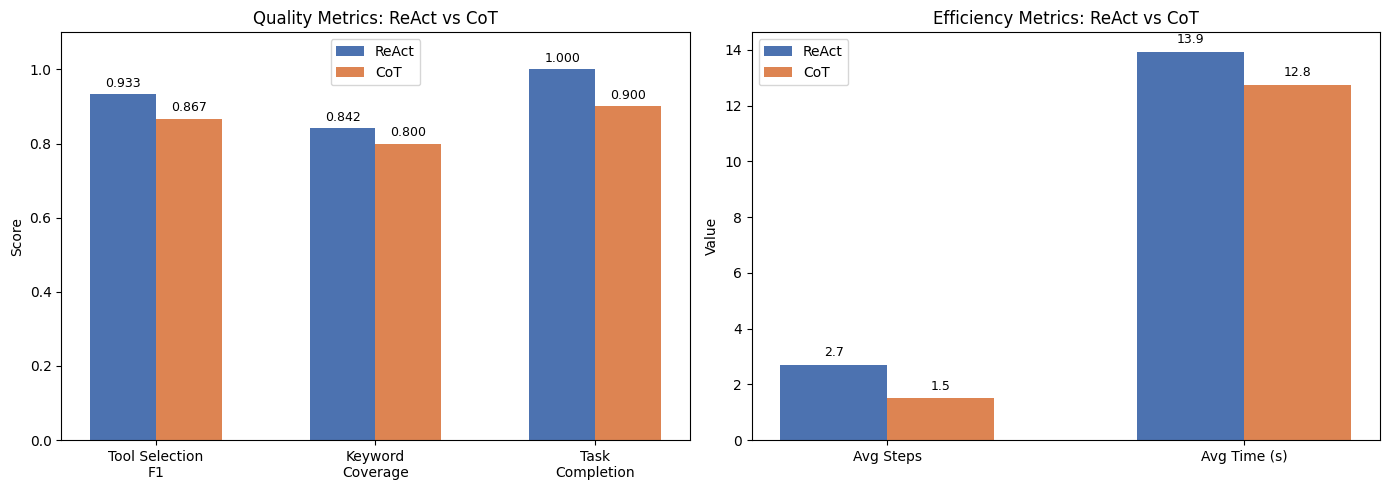

Chart saved to react_vs_cot_comparison.png


In [22]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["Tool Selection\nF1", "Keyword\nCoverage", "Task\nCompletion"]
react_vals = [df['react_tool_f1'].mean(), df['react_keywords'].mean(), (df['react_keywords'] > 0).mean()]
cot_vals = [df['cot_tool_f1'].mean(), df['cot_keywords'].mean(), (df['cot_keywords'] > 0).mean()]

x = np.arange(len(metrics))
width = 0.3

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Quality metrics
ax1 = axes[0]
ax1.bar(x - width/2, react_vals, width, label='ReAct', color='#4C72B0')
ax1.bar(x + width/2, cot_vals, width, label='CoT', color='#DD8452')
ax1.set_ylabel('Score')
ax1.set_title('Quality Metrics: ReAct vs CoT')
ax1.set_xticks(x)
ax1.set_xticklabels(metrics)
ax1.set_ylim(0, 1.1)
ax1.legend()
for i, (r, c) in enumerate(zip(react_vals, cot_vals)):
    ax1.text(i - width/2, r + 0.02, f'{r:.3f}', ha='center', fontsize=9)
    ax1.text(i + width/2, c + 0.02, f'{c:.3f}', ha='center', fontsize=9)

# Chart 2: Efficiency metrics
ax2 = axes[1]
eff_metrics = ["Avg Steps", "Avg Time (s)"]
react_eff = [df['react_steps'].mean(), df['react_time'].mean()]
cot_eff = [df['cot_steps'].mean(), df['cot_time'].mean()]
x2 = np.arange(len(eff_metrics))
ax2.bar(x2 - width/2, react_eff, width, label='ReAct', color='#4C72B0')
ax2.bar(x2 + width/2, cot_eff, width, label='CoT', color='#DD8452')
ax2.set_ylabel('Value')
ax2.set_title('Efficiency Metrics: ReAct vs CoT')
ax2.set_xticks(x2)
ax2.set_xticklabels(eff_metrics)
ax2.legend()
for i, (r, c) in enumerate(zip(react_eff, cot_eff)):
    ax2.text(i - width/2, r + 0.3, f'{r:.1f}', ha='center', fontsize=9)
    ax2.text(i + width/2, c + 0.3, f'{c:.1f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig("react_vs_cot_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to react_vs_cot_comparison.png")

# 6. Evaluation - Statistical Significance

In [23]:
from scipy import stats

# Test if ReAct keyword coverage is significantly different from CoT
t_stat, p_value = stats.mannwhitneyu(
    df['react_keywords'].values,
    df['cot_keywords'].values,
    alternative='two-sided'
)
print(f"Keyword Coverage: U-statistic={t_stat:.3f}, p-value={p_value:.3f}")
print(f"Significant difference (p<0.05): {p_value < 0.05}")

t_stat2, p_value2 = stats.mannwhitneyu(
    df['react_tool_f1'].values,
    df['cot_tool_f1'].values,
    alternative='two-sided'
)
print(f"\nTool Selection F1: U-statistic={t_stat2:.3f}, p-value={p_value2:.3f}")
print(f"Significant difference (p<0.05): {p_value2 < 0.05}")

Keyword Coverage: U-statistic=48.500, p-value=0.929
Significant difference (p<0.05): False

Tool Selection F1: U-statistic=51.000, p-value=0.957
Significant difference (p<0.05): False


# 6. Evaluation - Ablation Study

In [24]:
# Ablation: Remove quote_search tool
ALL_TOOLS_NO_QUOTES = [web_search, wikipedia_search, fetch_pdf, generate_citation]

def run_react_no_quotes(query, verbose=False):
    llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.0)
    agent = create_tool_calling_agent(llm=llm, tools=ALL_TOOLS_NO_QUOTES, prompt=prompt)
    executor = AgentExecutor(
        agent=agent, tools=ALL_TOOLS_NO_QUOTES, verbose=verbose,
        max_iterations=8, handle_parsing_errors=True,
        return_intermediate_steps=True,
    )
    result = executor.invoke({"input": query})
    steps = result.get("intermediate_steps", [])
    tools_used = [step[0].tool for step in steps]
    return {"output": result["output"], "num_steps": len(steps), "tools_used": tools_used}

# Test on quote-related questions only
quote_qs = [q for q in comparison_questions if "quote" in q["question"].lower()]

print("ABLATION: With vs Without quote_search")
print("=" * 60)
for q in quote_qs:
    print(f"\n{q['id']}: {q['question'][:50]}...")

    r_with = run_react(q["question"], verbose=False)
    r_without = run_react_no_quotes(q["question"], verbose=False)

    kw_with = keyword_cov(q["keywords"], r_with["output"])
    kw_without = keyword_cov(q["keywords"], r_without["output"])

    print(f"  WITH:    tools={r_with['tools_used']}, keyword_cov={kw_with:.2f}")
    print(f"  WITHOUT: tools={r_without['tools_used']}, keyword_cov={kw_without:.2f}")

ABLATION: With vs Without quote_search

q04: Find 3 quotes from the Transformer paper about why...
  WITH:    tools=['find_paper_quotes', 'quote_search'], keyword_cov=1.00
  WITHOUT: tools=['web_search', 'fetch_pdf', 'fetch_pdf', 'fetch_pdf', 'fetch_pdf', 'fetch_pdf', 'fetch_pdf', 'fetch_pdf'], keyword_cov=0.00

q09: Find quotes from the Transformer paper about the t...
  WITH:    tools=['quote_search'], keyword_cov=0.33
  WITHOUT: tools=['web_search', 'web_search', 'fetch_pdf', 'fetch_pdf', 'fetch_pdf'], keyword_cov=1.00


# 7. Demo

In [25]:
import gradio as gr
from pathlib import Path
import sys

project_dir = Path.cwd()
if str(project_dir) not in sys.path:
    sys.path.append(str(project_dir))

loaded_upload_path = None
last_upload_error = ""

def extract_text_from_uploaded_file(uploaded_file) -> str:
    global last_upload_error
    last_upload_error = ""
    path = uploaded_file.name if hasattr(uploaded_file, "name") else str(uploaded_file)
    ext = os.path.splitext(path)[1].lower()

    if ext == ".pdf":
        with open(path, "rb") as f:
            text = extract_text_from_pdf_bytes(f.read())
        if text.strip():
            return text

        # Optional OCR fallback for scanned/image-only PDFs.
        # Requires: tesseract + poppler system packages, plus pdf2image/pytesseract/pillow.
        try:
            from extract_pdf_text_with_ocr import extract_text_with_ocr
            return extract_text_with_ocr(Path(path))
        except Exception as e:
            last_upload_error = str(e)
            return ""

    with open(path, "rb") as f:
        data = f.read()
    try:
        return data.decode("utf-8")
    except UnicodeDecodeError:
        return data.decode("latin-1")

def maybe_load_uploaded_quote_source(source_file):
    global loaded_upload_path

    if source_file is None:
        if loaded_upload_path is not None:
            loaded_upload_path = None
            return reset_quote_source_to_default()
        return ""

    path = source_file.name if hasattr(source_file, "name") else str(source_file)
    if path == loaded_upload_path:
        return f"Quote source: {quote_source_name}"

    source_text = extract_text_from_uploaded_file(source_file)
    if not source_text.strip():
        detail = f" OCR error: {last_upload_error}" if last_upload_error else ""
        return "Uploaded file did not contain extractable text. If this is a scanned/image PDF, install OCR dependencies first; keeping the previous quote source." + detail

    loaded_upload_path = path
    return rebuild_quote_index(source_text, os.path.basename(path))

def is_quote_request(question: str) -> bool:
    return bool(re.search(r"\b(quote|quotes|verbatim|evidence|support|supporting|cite|citation)\b", question.lower()))

def is_document_summary_request(question: str) -> bool:
    q = question.lower()
    return bool(re.search(r"\b(pdf|document|uploaded|file|summarize|summary)\b|what does .* say|what is .* about", q))

def is_paper_reference_request(question: str) -> bool:
    q = question.lower()
    return bool(re.search(r"\b(papers?|sources?|references?|citations?)\b", q) and re.search(r"\b(quote|quotes|evidence|support|supporting|reference|cite)\b", q))

def answer_question(question, strategy, source_file=None):
    question = normalize_query(question)
    try:
        source_status = maybe_load_uploaded_quote_source(source_file)
    except Exception as e:
        source_status = f"Could not load uploaded quote source: {e}"

    if source_status.startswith("Uploaded file did not contain extractable text") and is_document_summary_request(question):
        result = {
            "output": "The uploaded file did not contain extractable text, so I cannot summarize that PDF without OCR. Please upload a text-based PDF, TXT, or MD file.",
            "tools_used": [],
            "num_steps": 0,
        }
    elif is_paper_reference_request(question):
        output = find_paper_quotes.invoke(question)
        result = {
            "output": output,
            "tools_used": ["find_paper_quotes"],
            "num_steps": 1,
        }
    elif is_quote_request(question):
        output = quote_search.invoke(question)
        result = {
            "output": output,
            "tools_used": ["quote_search"],
            "num_steps": 1,
        }
    elif is_document_summary_request(question):
        output = summarize_active_document.invoke(question)
        result = {
            "output": output,
            "tools_used": ["summarize_active_document"],
            "num_steps": 1,
        }
    elif strategy == "ReAct":
        result = run_react(question, verbose=False)
    else:
        result = run_cot(question, verbose=False)

    trace_lines = [f"Strategy: {strategy}"]
    if source_status:
        trace_lines.append(source_status)
    if "quote_search" in result["tools_used"] and not source_status:
        trace_lines.append(f"Quote source: {quote_source_name}")
    trace_lines.extend([
        f"Tools used: {result['tools_used']}",
        f"Steps: {result['num_steps']}",
    ])
    tools_info = "\n".join(trace_lines)
    return result["output"], tools_info

demo = gr.Interface(
    fn=answer_question,
    inputs=[
        gr.Textbox(label="Research Question", lines=2,
                   placeholder="e.g. What is RAG and how does it reduce hallucinations?"),
        gr.Radio(["ReAct", "Chain-of-Thought"], label="Agent Strategy", value="ReAct"),
        gr.File(label="Optional quote source (PDF/TXT/MD)", file_types=[".pdf", ".txt", ".md"], type="filepath"),
    ],
    outputs=[
        gr.Textbox(label="Answer", lines=15),
        gr.Textbox(label="Agent Trace", lines=4),
    ],
    title="Research Assistant Agent",
    description="STAT GR5293 — Tool-augmented LLM agent that searches the web, queries Wikipedia, fetches PDFs, extracts verified quotes from the active document, and generates citations.",
    examples=[
        ["What is RAG and how does it reduce hallucinations?", "ReAct", None],
        ["Find quotes from the active document about self-attention.", "ReAct", None],
        ["Compare GPT-4 and LLaMA 3 architectures.", "Chain-of-Thought", None],
        ["What is LoRA and why is it efficient?", "ReAct", None],
    ],
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c0ec4f354809951a9a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
